In [1]:
# 3D dataset : Extract diverse 2D slices 
# Slices should cover all the different classes,
# But also be as diverse as possible (not always centered to each class)


import pickle
from pathlib import Path
from hydra import compose, initialize_config_dir

# Get config path relative to notebook location (2 levels up to ic_segmentation/)
notebook_dir = Path.cwd()
print(f"Notebook directory: {notebook_dir}")
config_path = "/nfs/norasys/notebooks/camaret/ic_segmentation/configs" #Path.cwd() / "ic_segmentation/configs"
with initialize_config_dir(config_dir=str(config_path), version_base=None):
    cfg = compose(config_name="train")
dataset_dir = Path(cfg.paths.dataset)
print(f"Dataset directory: {dataset_dir}")


Notebook directory: /nfs/norasys/notebooks/camaret/ic_segmentation/notebooks/datasets
Dataset directory: /nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/totalseg


In [4]:
cfg.paths.totalseg2d_every_n_slice_stats

'/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/$totalseg2d_every_n_slice/stats.pkl'

In [8]:
# List all files in the dataset directory
all_folders = list(dataset_dir.iterdir())
print(f"nb of folders: {len(all_folders)}")

nb of folders: 1234


In [ ]:
#open ct.nii.gz
import nibabel as nib
case_folder = all_folders[0]
ct_path = case_folder / "ct.nii.gz"
ct_nib = nib.load(ct_path)
print(f"CT shape: {ct_nib.shape}")
print(f"CT affine: {ct_nib.affine}")
ct_data = ct_nib.get_fdata()
print(f"CT data type: {ct_data.dtype}")
print(f"CT data min: {ct_data.min()}")
print(f"CT data max: {ct_data.max()}")

CT shape: (297, 297, 237)
CT affine: [[   1.5           0.            0.         -234.56445312]
 [   0.            1.5           0.         -122.56445312]
 [   0.            0.            1.5        -510.        ]
 [   0.            0.            0.            1.        ]]


In [13]:
# list all files in case_folder/segmentations
segmentations_folder = case_folder / "segmentations"
segmentations_files = list(segmentations_folder.iterdir())
print(f"Segmentation files: {[f.name for f in segmentations_files]}")
# save segmentations in a unique array of shape (x, y, z, n_classes)
import numpy as np
segmentations_data = []
for seg_file in segmentations_files:
    seg_nib = nib.load(seg_file)
    seg_data = seg_nib.get_fdata()
    print(f"Segmentation {seg_file.name} shape: {seg_data.shape}")
    print(f"Segmentation {seg_file.name} data type: {seg_data.dtype}")
    print(f"Segmentation {seg_file.name} data min: {seg_data.min()}")
    print(f"Segmentation {seg_file.name} data max: {seg_data.max()}")
    segmentations_data.append(seg_data)
segmentations_data = np.stack(segmentations_data, axis=-1)
print(f"Segmentations data shape: {segmentations_data.shape}")

Segmentation files: ['vertebrae_C5.nii.gz', 'common_carotid_artery_left.nii.gz', 'clavicula_right.nii.gz', 'brachiocephalic_vein_left.nii.gz', 'heart.nii.gz', 'trachea.nii.gz', 'vertebrae_T2.nii.gz', 'rib_right_9.nii.gz', 'rib_right_4.nii.gz', 'vertebrae_L2.nii.gz', 'thyroid_gland.nii.gz', 'urinary_bladder.nii.gz', 'vertebrae_C7.nii.gz', 'humerus_left.nii.gz', 'pulmonary_vein.nii.gz', 'costal_cartilages.nii.gz', 'spinal_cord.nii.gz', 'vertebrae_T11.nii.gz', 'scapula_right.nii.gz', 'inferior_vena_cava.nii.gz', 'prostate.nii.gz', 'rib_left_2.nii.gz', 'rib_right_6.nii.gz', 'vertebrae_S1.nii.gz', 'sacrum.nii.gz', 'autochthon_right.nii.gz', 'vertebrae_C1.nii.gz', 'lung_lower_lobe_right.nii.gz', 'subclavian_artery_right.nii.gz', 'aorta.nii.gz', 'rib_left_9.nii.gz', 'iliac_vena_left.nii.gz', 'lung_middle_lobe_right.nii.gz', 'kidney_left.nii.gz', 'rib_right_10.nii.gz', 'iliopsoas_right.nii.gz', 'vertebrae_T6.nii.gz', 'rib_left_4.nii.gz', 'liver.nii.gz', 'humerus_right.nii.gz', 'rib_left_11.nii

In [15]:
# check if label overlap exists (if sum across classes is > 1)
label_overlap = np.sum(segmentations_data, axis=-1) > 1
print(f"positions of label overlap: {np.where(label_overlap)}")

positions of label overlap: (array([ 46,  46,  46, ..., 262, 262, 262], shape=(1629,)), array([166, 166, 167, ..., 181, 182, 183], shape=(1629,)), array([18, 19, 17, ...,  8,  9, 10], shape=(1629,)))


In [26]:
# axis-wise distribution of classes
axis_idx = 0
class_idx = 0
class_distribution = np.sum(segmentations_data[..., class_idx], axis=axis_idx)
print(f"Class {class_idx} distribution along axis {axis_idx}: {class_distribution}")

# all classes, all slices over [0, 1, 2] - axis_idx
classes_distributions = np.zeros((segmentations_data.shape[-1], segmentations_data.shape[axis_idx]))
for class_idx in range(segmentations_data.shape[-1]):
    # sum over all axes except axis_idx and class_idx
    axes_to_sum = tuple(i for i in range(len(segmentations_data.shape[:-1])) if i != axis_idx)
    classes_distributions[class_idx] = np.sum(segmentations_data[..., class_idx], axis=axes_to_sum)


Class 0 distribution along axis 0: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


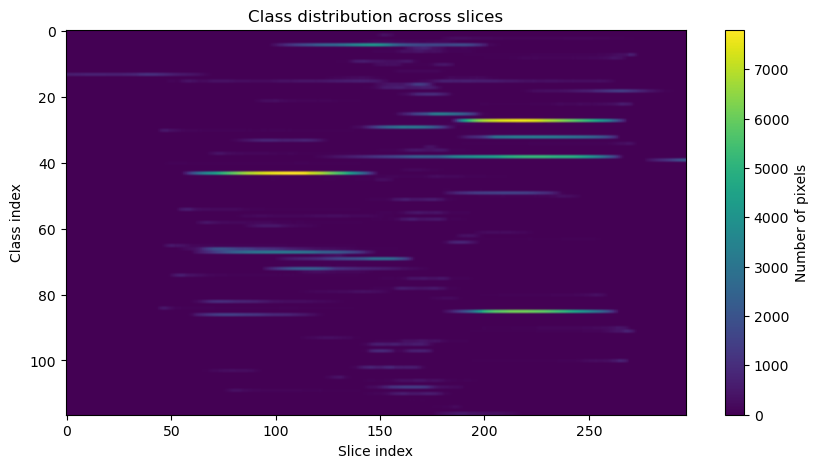

In [27]:
# plot row-wise as a heatmap
classes_distributions = np.stack(classes_distributions, axis=0)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.imshow(classes_distributions, aspect='auto', cmap='viridis')
plt.colorbar(label='Number of pixels')
plt.xlabel('Slice index')
plt.ylabel('Class index')
plt.title('Class distribution across slices')
plt.show()

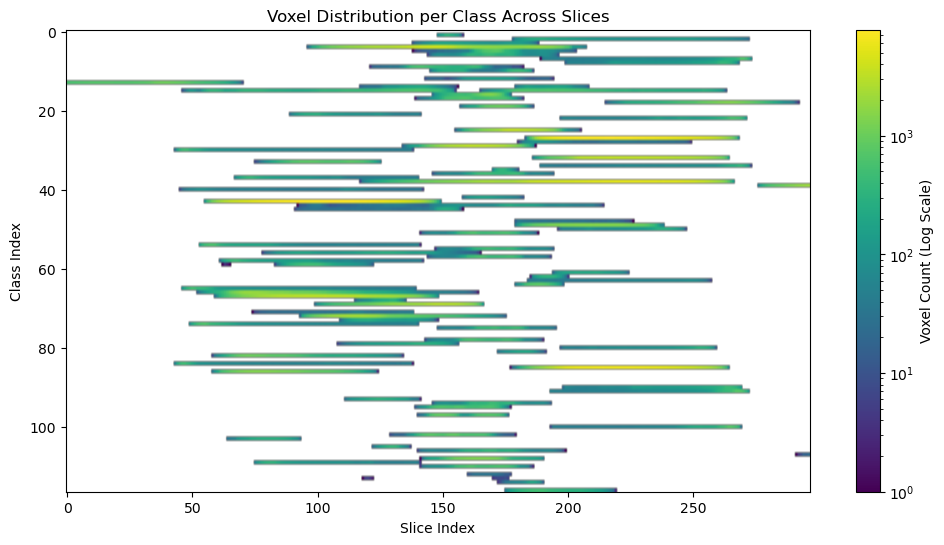

In [33]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(figsize=(12, 6))

# We use LogNorm() because large structures (like background or liver) 
# will otherwise completely wash out the colors of tiny structures.
plt.imshow(classes_distributions, aspect='auto', cmap='viridis', norm=LogNorm(vmin=1))

plt.colorbar(label='Voxel Count (Log Scale)')
plt.xlabel('Slice Index')
plt.ylabel('Class Index')
plt.title('Voxel Distribution per Class Across Slices')
plt.show()

In [62]:
from scipy.stats import entropy

nb_selected_slices = 10
# Calculate entropy for every slice (axis=0 sums over the classes)

selected_slices = []
slice_entropies = entropy(classes_distributions, axis=0)
selected_slices.extend(np.argsort(slice_entropies)[-nb_selected_slices:])  # top nb_selected_slices most diverse slices

# or select slices with the most classes present (non-zero classes)
#selected_slices = np.argsort(np.sum(classes_distributions > 0, axis=0))[-nb_selected_slices:] 

# or extract every Nth slice (e.g., every 10th slice), which is a simple heuristic to get a spread of slices across the volume

selected_slices.extend(np.arange(0, classes_distributions.shape[1], max(1, classes_distributions.shape[1] // nb_selected_slices)))


# or extract some defined percentiles of the distribution of each class across the slices, and then consolidate to unique slices
"""
# 1. Calculate the Cumulative Distribution Function (CDF) for each class
cumsum = np.cumsum(classes_distributions, axis=1)
totals = cumsum[:, -1:] # Total voxels per class across the whole axis

# Normalize to [0, 1], avoiding division by zero for classes that aren't in this volume
cdf = np.divide(cumsum, totals, out=np.zeros_like(cumsum), where=totals!=0)

# 2. Define target percentiles (e.g., near the start, the median, and near the end)
target_percentiles = [0.15, 0.5, 0.85]

candidate_slices = []
valid_classes_mask = totals.flatten() > 0

# 3. Find the slice index where each class hits the target percentiles
for p in target_percentiles:
    # np.argmax on a boolean array returns the index of the first True value
    indices = np.argmax(cdf[valid_classes_mask] >= p, axis=1)
    candidate_slices.extend(indices)

# 4. Consolidate to unique slices
unique_slices = np.unique(candidate_slices)

# 5. Filter down to exact nb_selected_slices (combining Heuristic 1 with your logic)
if len(unique_slices) > nb_selected_slices:
    # Count how many classes are present in each candidate slice
    classes_present = np.sum(classes_distributions[:, unique_slices] > 0, axis=0)
    
    # Sort the candidate slices by how many classes they contain, and take the top N
    best_candidate_indices = np.argsort(classes_present)[-nb_selected_slices:]
    selected_slices = unique_slices[best_candidate_indices]
else:
    selected_slices = unique_slices
"""
# get all class present in the original volume
original_classes = np.where(np.sum(segmentations_data, axis=(0, 1, 2)) > 0)[0]
print(f"Original classes in the volume: {len(original_classes)} - {original_classes}")

# 1. Classes NOT present in the original volume at all
# (Faster way: use classes_distributions since it's already summed over spatial axes)
missing_from_volume = np.where(np.sum(classes_distributions, axis=1) == 0)[0]
print(f"Classes completely missing from volume: {len(missing_from_volume)} - {missing_from_volume}")

# 2. Classes actually PRESENT in the selected slices (Notice the > 0)
present_in_selected = np.where(np.sum(classes_distributions[:, selected_slices], axis=1) > 0)[0]
print(f"Classes captured in selection: {len(present_in_selected)} - {present_in_selected}")

# 3. Classes we missed: Present in original volume, but NOT in the selected slices
missed_classes = np.setdiff1d(original_classes, present_in_selected)
print(f"Classes missed by the heuristic: {len(missed_classes)} - {missed_classes}")



Original classes in the volume: 89 - [  1   2   3   4   5   6   7   8   9  10  12  13  14  15  16  17  18  19
  21  22  25  27  28  29  30  32  33  34  35  36  37  38  39  40  42  43
  44  45  48  49  50  51  54  55  56  57  58  59  61  62  63  64  65  66
  67  68  69  71  72  73  74  75  78  79  80  81  82  84  85  86  90  91
  93  94  95  97 100 102 103 105 106 107 108 109 110 112 113 114 116]
Classes completely missing from volume: 28 - [  0  11  20  23  24  26  31  41  46  47  52  53  60  70  76  77  83  87
  88  89  92  96  98  99 101 104 111 115]
Classes captured in selection: 84 - [  2   3   4   5   6   7   8   9  10  12  13  14  15  16  17  18  19  21
  22  25  27  28  29  30  32  33  34  35  36  37  38  39  40  42  43  44
  45  48  49  50  51  54  55  56  57  58  59  61  63  65  66  67  68  69
  71  72  73  74  75  78  79  80  81  82  84  85  86  90  91  93  94  95
  97 100 102 103 106 108 109 110 112 113 114 116]
Classes missed by the heuristic: 5 - [  1  62  64 105 107]


In [9]:
# see stats of every_n extraction method 
stats_path = "/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/$totalseg2d_every_n_slice/stats.pkl"
#stats_path = "/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/totalseg/totalseg_stats.pkl"
import pickle


with open(stats_path, 'rb') as f:
    stats = pickle.load(f)

In [6]:
stats["s1106"]["sternum"]

{'bbox': ((61, 86), (81, 109), (36, 91)),
 'volume': 8231,
 'center': (73, 95, 63),
 'spacing_3d': (1.5, 1.5, 1.5),
 'slice_indices': {'z': [61, 66, 71, 76, 81, 86],
  'y': [81, 86, 91, 96, 101, 106],
  'x': [36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86, 91]},
 'num_slices': {'z': 6, 'y': 6, 'x': 12}}

In [10]:
stats["s1106"]["sternum"]

{'bbox': ((61, 86), (81, 109), (36, 91)),
 'volume': 8231,
 'center': (73, 95, 63),
 'spacing_3d': (1.5, 1.5, 1.5),
 'slice_indices': {'z': 79, 'y': 104, 'x': 50},
 'slice_coverage': {'z': 418, 'y': 444, 'x': 203}}

In [2]:
import sys
sys.path.append("/nfs/norasys/notebooks/camaret/ic_segmentation")

from src.dataloaders.totalseg2d_dataloader_fast import (
    get_dataloader as get_totalseg2d_dataloader,
)


In [3]:
val_loader = get_totalseg2d_dataloader(
    root_dir=cfg.paths.totalseg2d_every_n_slice,
    stats_path=cfg.paths.totalseg2d_every_n_slice_stats,
    label_id_list="train",
    context_size=cfg.context_size,
    batch_size=cfg.val_batch_size,
    image_size=tuple([256,256]),
    crop_to_bbox=cfg.preprocessing.crop_to_bbox,
    bbox_padding=cfg.preprocessing.bbox_padding,
    num_workers=cfg.training.get("num_workers", 4),
    split="train",
    shuffle=False,
    random_context=False,
    max_ds_len=100,
    random_coloring_nb=cfg.get("random_coloring_nb", 0),
    max_labels=cfg.get("max_labels", None),
)

Loaded stats for 200 cases
Filtered to 180 cases for split 'train'
Scanning 180 HDF5 files...


Scanning H5 files: 100%|██████████| 180/180 [00:00<00:00, 267.06it/s]


Built mapping for 59 labels.
Created 229004 samples (modality=ct)
Shuffled samples
